# IMPORT PACKAGES

In [297]:
import os
import pandas as pd
from bs4 import BeautifulSoup
from pathlib import Path
from collections import defaultdict
import escher
import cobra
from cobra.io import read_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from cobra.flux_analysis import single_gene_deletion
import matplotlib.pyplot as plt
import re
from re import match
import numpy as np
from pandas import read_xml
import matplotlib.pyplot as plt
import matplotlib as mpl


## Setup - Load model, save path and key IDs

In [298]:
# State the path to the file.xml
sbml_fname = 'S_fredii_970.xml'
# Read the model
model = read_sbml_model(sbml_fname)
reference = "https://doi.org/10.3389/fbioe.2024.1377334"
species_name = "Sinorhizobium fredii"

# Create save folder
save_path = f"Results_{sbml_fname.replace('.xml','')}"
os.makedirs(save_path, exist_ok=True)

CHECK MODEL INFORMATION

In [299]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
succ[e],r_0325,1.38,4,10.44%
homocitrate[e],r_0326,0.007782,7,0.10%
fe2[e],r_0327,0.03891,0,0.00%
n2[e],r_0328,0.3891,0,0.00%
pi[e],r_0330,0.03113,0,0.00%
so4[e],r_0333,0.04669,0,0.00%
o2[e],r_0334,0.4124,0,0.00%
h2o[e],r_0335,0.1906,0,0.00%
h[e],r_0336,7.687,0,0.00%
glu__L[e],r_0337,2,5,18.91%


biomasss for analyse growth rate (FBA)
model.objective = rxnBIOMASS 

In [300]:
matches = [m for m in model.reactions if 'nh3' in m.name.lower()]
for m in matches:
    print(m.id, m.name)

In [301]:
biomass_id = "BIOMASS_0508"
NH3_id = "r_0505"

In [302]:
# maximum growth rate 
max_growth_rate = model.slim_optimize()
with open(os.path.join(save_path, f"max_growth_{model.name}.txt"), "w") as f:
    f.write(f"Max growth rate: {max_growth_rate}\n")
print(f"Maximum growth rate: {max_growth_rate:.4f} h-1")

Maximum growth rate: 0.9528 h-1


In [303]:
matches = [m for m in model.reactions if 'nh3' in m.name.lower()]
for m in matches:
    print(m.id, m.name)

## PART 1 - LOAD MODEL

Reads the SBML genome-scale model. model.reaction / metabolites / genes are COBRA.py objects. Currently model.objective was set to the default reaction defined in the SBML file. (Normally, biomass)

In [304]:
model = read_sbml_model(sbml_fname)

print(f"\nModel ID   : {model.id}")
print(f"Model name : {model.name}")
print(f"Metabolites: {len(model.metabolites)}")
print(f"Reactions  : {len(model.reactions)}")
print(f"Genes      : {len(model.genes)}")
print(f"Objective  : {model.objective}")


Model ID   : M_iAQY970
Model name : Model Exported from COBRA Toolbox
Metabolites: 942
Reactions  : 1052
Genes      : 970
Objective  : Maximize
1.0*BIOMASS_0508 - 1.0*BIOMASS_0508_reverse_206d3


In [305]:

# Which reactions are currently set as the objective (coefficient = 1)?
# This confirms the solver is set to maximise biomass (= growth rate).
obj_rxns = [r for r in model.reactions if r.objective_coefficient == 1]
print("\nObjective reactions:", [r.id for r in obj_rxns])


Objective reactions: ['BIOMASS_0508']


In [306]:
model.optimize()
model_summary = model.summary()
print(model_summary)

# save the model summary to a text file
with open(os.path.join(save_path, f"model_summary_{model.name}.txt"), "w") as f:
    f.write(str(model_summary)) 

Objective
1.0 BIOMASS_0508 = 0.9528115434140285

Uptake
------
    Metabolite Reaction     Flux  C-Number C-Flux
       succ[e]   r_0325     1.38         4 10.44%
homocitrate[e]   r_0326 0.007782         7  0.10%
        fe2[e]   r_0327  0.03891         0  0.00%
         n2[e]   r_0328   0.3891         0  0.00%
         pi[e]   r_0330  0.03113         0  0.00%
        so4[e]   r_0333  0.04669         0  0.00%
         o2[e]   r_0334   0.4124         0  0.00%
        h2o[e]   r_0335   0.1906         0  0.00%
          h[e]   r_0336    7.687         0  0.00%
     glu__L[e]   r_0337        2         5 18.91%
      inost[e]   r_0338     0.01         6  0.11%
     mal__L[e]   r_0340     1.44         4 10.89%
        mg2[e]   r_0341 0.007782         0  0.00%
       cbl1[e]   r_0342 0.007782        62  0.91%
       mobd[e]   r_0343 0.007782         0  0.00%
        thm[e]   r_0344 0.007782        12  0.18%
        zn2[e]   r_0510 0.007782         0  0.00%
         pl[c]   r_0902  0.02335     

## PART 2 - BOUNDARY REACTION AND ID EXPORT 
Exchange (boundary) reaction connect the model to its environment. Negative lower bound = the cell can take up that metabolites. Positive upper bound = the cell can secrete it. Export these to CSV/TSV so it can browse all availble nutrients and verify reaction IDs.

In [307]:
reaction_ids = [r.id for r in model.reactions]
reaction_names = [r.name for r in model.reactions]
reaction_lower_bounds = [r.lower_bound for r in model.reactions]
reaction_upper_bounds = [r.upper_bound for r in model.reactions]

In [308]:
exchange_rows = []
with open(os.path.join(save_path, "boundary_reactions.txt"), "w") as f:
    header = f"{'Reaction ID':20} | {'Reaction Name':50} | {'Lower Bound':15} | {'Upper Bound':15}"
    f.write(header + "\n" + "-" * len(header) + "\n")
    for r in model.boundary:
        line = f"{r.id:20} | {r.name:50} | {r.lower_bound:15} | {r.upper_bound:15}"
        f.write(line + "\n")
        exchange_rows.append({
            "Reaction ID": r.id,
            "Reaction Name": r.name,
            "Lower Bound": r.lower_bound,
            "Upper Bound": r.upper_bound
        })

boundary_df = pd.DataFrame(exchange_rows)
boundary_df.to_csv(os.path.join(save_path, "boundary_reactions.csv"), index=False)
boundary_df.to_csv(os.path.join(save_path, "boundary_reactions.tsv"), sep="\t", index=False)

print(f"Successfully saved {len(boundary_df)} boundary reactions to {save_path}/boundary_reactions.txt, .csv, and .tsv")

Successfully saved 90 boundary reactions to Results_S_fredii_970/boundary_reactions.txt, .csv, and .tsv


Reaction and metabolite export

In [309]:
reaction_data = [{
    "current_id":      r.id,
    "name":            r.name,
    "reaction_string": r.build_reaction_string(),
    "subsystem":       r.subsystem,
    "lower_bound":     r.lower_bound,
    "upper_bound":     r.upper_bound,
}
for r in model.reactions]

metabolites_data = [{
    "current_id": m.id,
    "name": m.name,
    "formula": m.formula,
    "charge": m.charge,
    "compartment": m.compartment,
}
for m in model.metabolites]

pd.DataFrame(reaction_data).to_csv(os.path.join(save_path, "reactions_mapping.csv"), index=False)
pd.DataFrame(metabolites_data).to_csv(os.path.join(save_path, "metabolites_mapping.csv"), index=False)

In [310]:
met_reactions = []

for m in model.metabolites:
    for r in m.reactions:
        met_reactions.append({
            "metabolites_id": m.id,
            "reaction_id": r.id,
            "name": m.name,
            "reaction_string": r.build_reaction_string(),
            "subsystem": r.subsystem,
            "lower_bound": r.lower_bound,
            "upper_bound": r.upper_bound,
            "formula": m.formula,
            "charge": m.charge,
            "compartment": m.compartment,
        })

pd.DataFrame(met_reactions).to_csv(os.path.join(save_path, "metabolites_reactions_mapping.csv"), index=False)

## PART 3 - BIOMASS OBJECTIVE
The biomass reaction represents growth rate. (growth rate, h-1)


In [311]:
biomass_reaction = [r for r in model.reactions if r.objective_coefficient == 1][0]
print(f"\nBiomass reaction: {biomass_reaction.id}")
print(f"Biomass reaction string: {biomass_reaction.build_reaction_string()}")


Biomass reaction: BIOMASS_0508
Biomass reaction string: 0.00816736 Symbiotic_Cofactors[c] + 0.816736 ade[c] + 0.816736 ala__L[c] + 0.816736 arg__L[c] + 0.816736 asp__L[c] + 0.816736 fixedNH3[c] + 0.816736 glycogen[c] + 0.816736 hdca[c] + 0.816736 ile__L[c] + 0.816736 phb[c] + 0.816736 ura[c] + 0.816736 val__L[c] <=> Symbiotic_product[c] + 0.816736 ala__L[e] + 0.816736 asp__L[e] + 0.816736 fixedNH3[e] + 0.816736 glycogen1[c]


## PART 4 - ENVIRONMENT SETUP (THREE SOIL CONDITIONS)
Each environment is modelled by setting exchange reaction lower bounds.
- Negative lower bound = maximum uptake rate (mmol gDW-1 h-1)
- Lower bound = 0, nutrient is unavailable

Three conditions: Bulk soil, Rhizosphere, Nodule (bacteroid)
Reference: [doi.org/10.1038/ncomms12219](https://doi.org/10.1038/ncomms12219)

Table 6: https://static-content.springer.com/esm/art%3A10.1038%2Fncomms12219/MediaObjects/41467_2016_BFncomms12219_MOESM588_ESM.pdf 

Bulk soil medium

Free-livinng state: diverse sugars, amino acids, aerobic, NH4+, NO3- present.

In [312]:
# load a fresh copy of the SBML model for bulk soil medium
model_bulk = read_sbml_model(sbml_fname)

for r in model_bulk.exchanges:
    r.lower_bound=0


In [313]:
# bulk soil 60 
bulk_medium = {
    #'EX_cpd00224_e0': -0.28889705,    #L-arabinose
    #'EX_cpd00108_e0': -0.25290619,    #D-galactose 
    #'EX_cpd00027_e0': -0.61972444,    #D-glucose 
    'r_1004': -0.2540567,     #D-mannose 
    'r_1052': -0.13913636,    #L-rhamnose 
    #'EX_cpd00154_e0': -0.21280795,    #Xylose
    #'EX_cpd00105_e0': -0.01862144,    #D-ribose
    'r_0988': 0,              #Sucrose
    #'EX_cpd00382_e0': 0,              #D-raffinose 
    #'EX_cpd01133_e0': 0,              #Stachyose
    'r_0325': -0.0056245,     #Succinate
    'r_0340': -0.03649016,    #L-malate 
    'r_0339': 0,              #L-aspartate 
    #'EX_cpd00161_e0': -0.0068175,     #L-threonine 
    #'EX_cpd00054_e0': 0,              #L-serine
    #'EX_cpd00023_e0': 0,              #L-glutamate 
    #'EX_cpd00129_e0': -0.01102953,    #L-proline 
    #'EX_cpd00033_e0': -0.0068175,     #Glycine 
    'r_0331': -0.02780553,    #L-alanine
    #'EX_cpd00156_e0': -0.02928849,    #L-valine 
    #'EX_cpd00084_e0': -0.0068175,     #L-cysteine 
    #'EX_cpd00322_e0': -0.0199273,     #L-isoleucine 
    #'EX_cpd00107_e0': -0.03596182,    #L-leucine 
    #'EX_cpd00069_e0': -0.0068175,     #L-tyrosine 
    #'EX_cpd00281_e0': 0,              #GABA
    #'EX_cpd00064_e0': -0.0068175,     #L-ornithine 
    #'EX_cpd00119_e0': -0.0068175,     #L-histidine 
    #'EX_cpd00051_e0': -0.0068175,     #L-arginine 
    #'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    # 'EX_cpd00013': -7.5,           #Ammonia NH3
    #'EX_cpd00209_e0': -7.5,           #Nitrate
    'r_0333': -15,            #Sulfate
    #'EX_cpd00009_e0': -15,            #Phosphate
    'r_0335': -15,            #H2O
    'r_0334': -15,            #O2
    'r_0329': -15,            #CO2
    # 'EX_cpd00030_e0': -15,            #Mn2
    'r_0510': -15,            #Zn2
    # 'EX_cpd00058_e0': -15,            #Cu2
    # 'EX_cpd00063_e0': -15,            #Ca2
    'r_0336': -15,            #H+  
    # 'EX_cpd00099_e0': -15,            #Cl- 
    # 'EX_cpd00104_e0': -15,            #Biotin
    # 'r_0909': -15,            #Co2 it has transporters but no exchange reaction
    # 'r_0871': -15,            #K+
    'r_0341': -15,            #Mg2+
    # 'EX_cpd00971_e0': -15,            #Na+
    'r_0327': -15,            #Fe2+ 
    # 'r_0952': -15,            #Fe3+ it is has transporters but no exchange reaction
    'r_0342': 0,              #Cob(I)alamin
    'r_0326': -1000,              #Homocitrate
    'r_0343': -1000,              #Molybdate
    'r_0344': 0,              #Thiamine
    'r_0338': -1000,              #M-inositol 
    'r_0328': -1000,              #N2 
    # 'EX_cpd00073_e0': 0,              #Urea
    # 'EX_cpd11416_c0': 0,              #Biomass
    # 'r_0945': 0,              #5-Methylthioadenosine it has transporters but no exchange reaction
    'r_0512': 0,              #H2
    'r_0505': -1000               #Fixed NH3
}

print("Setting exchange bounds:")
for comp_id, bound in bulk_medium.items():
    if comp_id in model_bulk.reactions:
        model_bulk.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds:


Rhizoshere medium
Near plant roots: more malate, succinate, sucrose, raffinose, stachyose from root cells.

In [314]:
# load a fresh copy of the SBML model for rhizoshere medium
model_rh = read_sbml_model(sbml_fname)

for r in model_rh.exchanges:
    r.lower_bound=0

In [315]:
# rhizoshere soil 60 
rh_medium = {
    # 'EX_cpd00224_e0': -0.26974143,    #L-arabinose
    # 'EX_cpd00108_e0': -0.18317325,    #D-galactose 
    # 'EX_cpd00027_e0': -0.04098397,    #D-glucose 
    'r_1004': -0.05436649,    #D-mannose 
    'r_1052': -0.02927426,    #L-rhamnose 
    # 'EX_cpd00154_e0': -0.04600242,    #Xylose
    # 'EX_cpd00105_e0': 0,              #D-ribose
    'r_0988': -0.02049199,    #Sucrose
    # 'EX_cpd00382_e0': -0.01024599,    #D-raffinose 
    # 'EX_cpd01133_e0': -0.03073798,    #Stachyose
    'r_0325': -0.12240603,    #Succinate
    'r_0340': -0.79413596,    #L-malate 
    'r_0339': -0.03205557,    #L-aspartate 
    # 'EX_cpd00161_e0': -0.00961667,    #L-threonine 
    # 'EX_cpd00054_e0': -0.01004986,    #L-serine
    # 'EX_cpd00023_e0': -0.0283302,     #L-glutamate 
    # 'EX_cpd00129_e0': 0,              #L-proline 
    # 'EX_cpd00033_e0': -0.00693094,    #Glycine 
    'r_0331': -0.00823049,    #L-alanine
    # 'EX_cpd00156_e0': -0.00337883,    #L-valine 
    # 'EX_cpd00084_e0': 0,              #L-cysteine 
    # 'EX_cpd00322_e0': -0.00186269,    #L-isoleucine 
    # 'EX_cpd00107_e0': -0.00303228,    #L-leucine 
    # 'EX_cpd00069_e0': -0.00233919,    #L-tyrosine 
    # 'EX_cpd00281_e0': 0,              #GABA
    # 'EX_cpd00064_e0': -0.00831712,    #L-ornithine 
    # 'EX_cpd00119_e0': -0.00506825,    #L-histidine 
    # 'EX_cpd00051_e0': -0.00948672,    #L-arginine 
    # 'EX_cpd00851_e0': -0.26974144,    #Trans-4-hydroxy-l-proline 
    # 'r_0119': -7.5,           #Ammonia 
    # 'EX_cpd00209_e0': -7.5,           #Nitrate
    'r_0333': -15,            #Sulfate
    # 'EX_cpd00009_e0': -15,            #Phosphate
    'r_0335': -15,            #H2O
    'r_0334': -15,            #O2
    'r_0329': -15,            #CO2
    # 'EX_cpd00030_e0': -15,            #Mn2
    'r_0510': -15,            #Zn2
    # 'EX_cpd00058_e0': -15,            #Cu2
    # 'EX_cpd00063_e0': -15,            #Ca2
    'r_0336': -15,            #H+  
    # 'EX_cpd00099_e0': -15,            #Cl- 
    # 'EX_cpd00104_e0': -15,            #Biotin
    # 'r_0909': -15,            #Co2 it has transporters but no exchange reaction
    'r_0871': -15,            #K+
    'r_0341': -15,            #Mg2+
    # 'EX_cpd00971_e0': -15,            #Na+
    'r_0327': -15,            #Fe2+ 
    # 'r_0952': -15,            #Fe3+ it has transporters but no exchange reaction
    'r_0342': -1000,              #Cob(I)alamin
    'r_0326': -1000,              #Homocitrate
    'r_0343': -1000,              #Molybdate
    'r_0344': -1000,              #Thiamine
    'r_0338': -1000,              #M-inositol 
    'r_0328': -1000,              #N2 
    # 'EX_cpd00073_e0': 0,              #Urea
    # 'EX_cpd11416_c0': 0,              #Biomass
    # 'r_0945': 0,              #5-Methylthioadenosine it has transporters but no exchange reaction
    'r_0512': -1000,              #H2
    'r_0505': -1000               #Fixed NH3
}

print("Setting exchange bounds rhizosphere:")
for comp_id, bound in rh_medium.items():
    if comp_id in model_rh.reactions:
        model_rh.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")


Setting exchange bounds rhizosphere:


Nodule medium

In [316]:
# load a fresh copy of the SBML model for nodule medium
model_no = read_sbml_model(sbml_fname)

for r in model_no.exchanges:
    r.lower_bound=0

In [317]:
# nodule soil 60 
nodule_medium = {
    # 'EX_cpd00224_e0': 0,              #L-arabinose
    # 'EX_cpd00108_e0': 0,              #D-galactose 
    # 'EX_cpd00027_e0': 0,              #D-glucose 
    'r_1004': 0.,             #D-mannose 
    'r_1052': 0.,             #L-rhamnose 
    # 'EX_cpd00154_e0': 0.,             #Xylose
    # 'EX_cpd00105_e0': 0.,             #D-ribose
    'r_0988': 0,              #Sucrose
    # 'EX_cpd00382_e0': 0,              #D-raffinose 
    # 'EX_cpd01133_e0': 0,              #Stachyose
    'r_0325': -1.326,         #Succinate (main carbon source for nodule)
    'r_0340': -1.1122,        #L-malate 
    'r_0339': 0,              #L-aspartate 
    # 'EX_cpd00161_e0': 0,              #L-threonine 
    # 'EX_cpd00054_e0': 0,              #L-serine
    # 'EX_cpd00023_e0': -2,             #L-glutamate (Nitrogen carrier back to plant)
    # 'EX_cpd00129_e0': 0,              #L-proline 
    # 'EX_cpd00033_e0': 0.,             #Glycine 
    'r_0331': 0.,             #L-alanine
    # 'EX_cpd00156_e0': 0.,             #L-valine 
    # 'EX_cpd00084_e0': 0,              #L-cysteine 
    # 'EX_cpd00322_e0': 0,              #L-isoleucine 
    # 'EX_cpd00107_e0': 0,              #L-leucine 
    # 'EX_cpd00069_e0': 0,              #L-tyrosine 
    # 'EX_cpd00281_e0': 0,              #GABA
    # 'EX_cpd00064_e0': 0,              #L-ornithine 
    # 'EX_cpd00119_e0': 0,              #L-histidine 
    # 'EX_cpd00051_e0': 0,              #L-arginine 
    # 'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    # 'r_0119': 0,              #Ammonia 
    # 'EX_cpd00209_e0': 0,              #Nitrate
    'r_0333': -1000,          #Sulfate
    # 'EX_cpd00009_e0': -1000,          #Phosphate
    'r_0335': -1000,          #H2O
    'r_0334': -1.26,          #O2 
    'r_0329': -1000,          #CO2
    # 'EX_cpd00030_e0': -1000,              #Mn2
    'r_0510': -1000,              #Zn2
    # 'EX_cpd00058_e0': -1000,              #Cu2
    # 'EX_cpd00063_e0': -1000,              #Ca2
    'r_0336': -1000,          #H+  
    # 'EX_cpd00099_e0': -1000,              #Cl- 
    # 'EX_cpd00104_e0': -1000,              #Biotin
    # 'r_0909': -1000,              #Co2 it has transporters but no exchange reaction
    'r_0871': -1000,              #K+
    'r_0341': -1000,          #Mg2+
    # 'EX_cpd00971_e0': -1000,              #Na+
    'r_0327': -1000,          #Fe2+ 
    # 'r_0952': -1000,              #Fe3+ it has transporters but no exchange reaction
    'r_0342': -1000,          #Cob(I)alamin
    'r_0326': -1000,          #Homocitrate
    'r_0343': -1000,          #Molybdate
    'r_0344': -1000,          #Thiamine
    'r_0338': -0.01,          #M-inositol 
    'r_0328': -1000,          #N2 
    # 'EX_cpd00073_e0': 0,              #Urea
    # 'EX_cpd11416_c0': 0,              #Biomass
    # 'r_0945': 0,              #5-Methylthioadenosine it has transporters but no exchange reaction
    'r_0512': -1000,              #H2
    'r_0505': -1000               #Fixed NH3
}

print("Setting exchange bounds nodule:")
for comp_id, bound in nodule_medium.items():
    if comp_id in model_no.reactions:
        model_no.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds nodule:


Build model copies for each environment 

In [318]:
model = read_sbml_model(sbml_fname)
def apply_medium(model_obj, medium):
    # reset exchange lower bounds then apply provided medium bounds
    for r in model_obj.exchanges:
        r.lower_bound = 0
    for comp_id, bound in medium.items():
        if comp_id in model_obj.reactions:
            model_obj.reactions.get_by_id(comp_id).lower_bound = bound
        else:
            print(f"WARNING: {comp_id} not found in model {model_obj.id}")


# model_bulk
model_bulk.objective = biomass_reaction
apply_medium(model_bulk, bulk_medium)

# model_rh
model_rh.objective = biomass_reaction
apply_medium(model_rh, rh_medium)

# model_no
model_no.objective = biomass_reaction
apply_medium(model_no, nodule_medium)


In [319]:
model_bulk.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Metabolite,Reaction,Flux,C-Number,C-Flux


In [320]:
model_rh.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
succ[e],r_0325,0.1224,4,0.00%
homocitrate[e],r_0326,0.8616,7,0.06%
fe2[e],r_0327,4.308,0,0.00%
n2[e],r_0328,43.08,0,0.00%
so4[e],r_0333,5.17,0,0.00%
o2[e],r_0334,15,0,0.00%
h2o[e],r_0335,15,0,0.00%
inost[e],r_0338,1000,6,59.93%
asp__L[e],r_0339,0.03206,4,0.00%
mal__L[e],r_0340,0.7941,4,0.03%


In [321]:
model_no.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
succ[e],r_0325,1.326,4,19.33%
homocitrate[e],r_0326,0.003944,7,0.10%
fe2[e],r_0327,0.01972,0,0.00%
n2[e],r_0328,0.1972,0,0.00%
so4[e],r_0333,0.02367,0,0.00%
o2[e],r_0334,0.2091,0,0.00%
h[e],r_0336,4.659,0,0.00%
inost[e],r_0338,0.01,6,0.22%
mal__L[e],r_0340,1.112,4,16.21%
mg2[e],r_0341,0.003944,0,0.00%


In [322]:
# save growth rate results to a text file
with open(os.path.join(save_path, "growth_rate_results.txt"), "w") as f:
    # save growth rate results to a text file
    solution_bulk = model_bulk.optimize()
    solution_rh = model_rh.optimize()
    solution_no = model_no.optimize()

    with open(os.path.join(save_path, "growth_rate_results.txt"), "w") as f:
        f.write(f"Status: \nBulk: {solution_bulk.status}, Rhizosphere: {solution_rh.status}, Nodule: {solution_no.status}\n")
        f.write(f"Growth rate: \nBulk: {solution_bulk.objective_value}, Rhizosphere: {solution_rh.objective_value}, Nodule: {solution_no.objective_value}\n")


## PART 5 - FLUX BALANCE ANALYSIS (FBA)
FBA solves a linear program: find all reaction flues that
1. Satisfy mass balance at every metabolite
2. Stay within reaction bounds
3. Maximise the objective (biomass = growth rate)

`solution.objective_value` = growth rate (h-1)
`solution.fluxes["rxn_id"]` = flux of any reacion at the optimum (mmol gDW-1 h-1) 

Reference from GitHub COBRA.py tutorial

https://github.com/migp11/cobrapy-tutorial

https://cobrapy.readthedocs.io/en/0.19.0/index.html

https://opencobra.github.io/cobratoolbox/stable/index.html

In [323]:
solution_bulk = model_bulk.optimize()
solution_rh = model_rh.optimize()
solution_no = model_no.optimize()

In [324]:
# to calculate the percentage of growth rate
print('Status: \n', solution_bulk.status, solution_rh.status, solution_no.status)
print('Growth rate: \n', solution_bulk.objective_value, solution_rh.objective_value, solution_no.objective_value)

Status: 
 optimal optimal optimal
Growth rate: 
 0.0 105.49561009236805 0.48295511813379766


maximum growth rate in each environment 


In [325]:
max_growth_bulk = solution_bulk.objective_value
max_growth_rh = solution_rh.objective_value
max_growth_no = solution_no.objective_value

In [326]:
print(
    f"Growth rate: \nBulk: {max_growth_bulk}, Rhizosphere: {max_growth_rh}, Nodule: {max_growth_no} "
)

Growth rate: 
Bulk: 0.0, Rhizosphere: 105.49561009236805, Nodule: 0.48295511813379766 


In [327]:
# save maximum growth rate each environment to a text file
with open(os.path.join(save_path, "max_growth_rate_each_env.txt"), "w") as f:
    f.write(f"Status: \nBulk: {solution_bulk.status}, Rhizosphere: {solution_rh.status}, Nodule: {solution_no.status}\n")
    f.write(f"Growth rate: \nBulk: {solution_bulk.objective_value}, Rhizosphere: {solution_rh.objective_value}, Nodule: {solution_no.objective_value}\n")   

biomass over time for 72 hours

In [328]:
X0 = 0.01  # starting biomass concentration (gDW/L)
t_hours = np.arange(0,73,1)  # time points from 0 to 72 hours

time_rows = []
for cond_name, solution in zip(['Bulk', 'Rhizosphere', 'Nodule'], [solution_bulk, solution_rh, solution_no]):
    growth_rate = solution.objective_value
    X_t = X0 * np.exp(growth_rate * t_hours)
    for t, biomass in zip(t_hours, X_t):
        time_rows.append({
            "Condition": cond_name,
            "Time (hours)": t,
            "Biomass (gDW/L)": biomass
        })

time_df = pd.DataFrame(time_rows)
time_df.to_csv(os.path.join(save_path, f"biomass_over_time_{model.name}.csv"), sep="\t" ,index=False)
print(f"Successfully saved biomass over time data to {save_path}/biomass_over_time_{model.name}.csv")

# Show biomass at 72 hours for each condition
for cond_name in ['Bulk', 'Rhizosphere', 'Nodule']:
    subset = time_df[time_df['Condition'] == cond_name]
    for t in [0, 24, 48, 72]:
        biomass_at_t = subset[subset['Time (hours)'] == t]['Biomass (gDW/L)'].values[0]
        print(f"Condition: {cond_name}, Time: {t} hours, Biomass: {biomass_at_t:.4f} gDW/L")  
    


Successfully saved biomass over time data to Results_S_fredii_970/biomass_over_time_Model Exported from COBRA Toolbox.csv
Condition: Bulk, Time: 0 hours, Biomass: 0.0100 gDW/L
Condition: Bulk, Time: 24 hours, Biomass: 0.0100 gDW/L
Condition: Bulk, Time: 48 hours, Biomass: 0.0100 gDW/L
Condition: Bulk, Time: 72 hours, Biomass: 0.0100 gDW/L
Condition: Rhizosphere, Time: 0 hours, Biomass: 0.0100 gDW/L
Condition: Rhizosphere, Time: 24 hours, Biomass: inf gDW/L
Condition: Rhizosphere, Time: 48 hours, Biomass: inf gDW/L
Condition: Rhizosphere, Time: 72 hours, Biomass: inf gDW/L
Condition: Nodule, Time: 0 hours, Biomass: 0.0100 gDW/L
Condition: Nodule, Time: 24 hours, Biomass: 1081.1198 gDW/L
Condition: Nodule, Time: 48 hours, Biomass: 116882005.5643 gDW/L
Condition: Nodule, Time: 72 hours, Biomass: 12636345230053.5098 gDW/L


C:\Users\pimni\AppData\Local\Temp\ipykernel_39160\3917160411.py:7: RuntimeWarning: overflow encountered in exp
  X_t = X0 * np.exp(growth_rate * t_hours)


plot 

In [329]:
COLORS = {"Bulk": "#0C447C", "Rhizosphere": "#378ADD", "Nodule": "#444441"}
conds = ["Bulk", "Rhizosphere", "Nodule"]

plot 1 growth rate bar in each environment

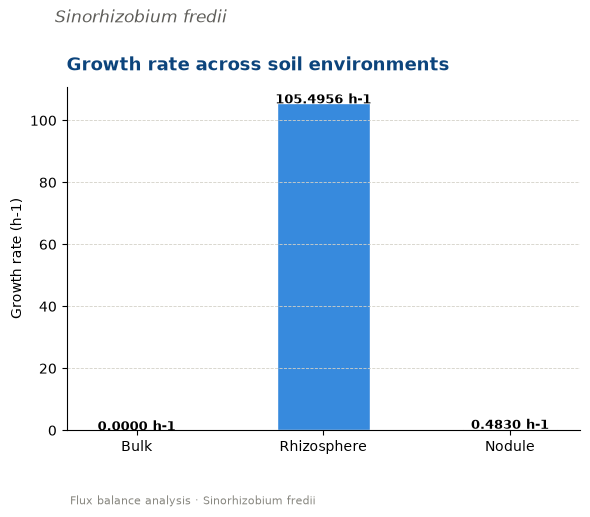

In [330]:
fig1, ax = plt.subplots(figsize=(6, 5))
mapping = {'Bulk': solution_bulk, 'Rhizosphere': solution_rh, 'Nodule': solution_no}
vals = [mapping[c].objective_value if getattr(mapping[c], "status", None) == "optimal" else 0 for c in conds]
bars = ax.bar(conds, vals, color=[COLORS[c] for c in conds], edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0003, f"{v:.4f} h-1", ha="center", fontsize=9, fontweight="bold")
fig1.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
ax.set_ylabel("Growth rate (h-1)")
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Growth rate across soil environments",
             fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig1.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig1.savefig(os.path.join(save_path, "1_growth_rate.png"), dpi=300)
plt.show()

plot 2 biomass over time 

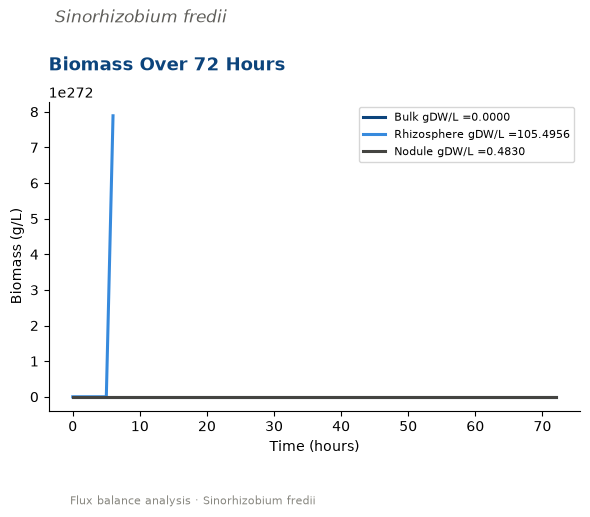

In [331]:
fig2, ax = plt.subplots(figsize=(6, 5))
for cond in conds:
    sub = time_df[time_df['Condition'] == cond].copy()
    sub = sub.rename(columns={'Time (hours)': 'time_h', 'Biomass (gDW/L)': 'biomass_gL'})
    sub['mu'] = mapping[cond].objective_value
    mu = sub["mu"].iloc[0]
    ax.plot(sub.time_h, sub.biomass_gL, color=COLORS[cond], linewidth=2.2, label=f"{cond} gDW/L ={mu:.4f}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Biomass (g/L)")
ax.set_title("Biomass Over 72 Hours", fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig2.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig2.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig2.savefig(os.path.join(save_path, "2_biomass_over_time.png"), dpi=300)
plt.show()

## PART 6 BIOMASS 
Biomass production rate is stepped from 0 to 90% of optimal.

biomass_id = "rxnBIOMASS"


In [332]:
solution = model.optimize()

In [333]:
f_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
solution = model.optimize()
growth_rate = solution.objective_value
biomass_value = []

for bio in f_values:
    model.reactions.get_by_id(biomass_id).lower_bound = bio*growth_rate
    solution = model.optimize()
    biomass_value.append({
        "Fraction": bio,
        "Biomass_rate_h-1": float(bio*growth_rate),
        "Max_growth_h-1": solution.objective_value
    })

# save 
df_biomass = pd.DataFrame(biomass_value)
df_biomass.to_csv(os.path.join(save_path,"biomass_value.csv"), index=False)

In [334]:
df_biomass

,Fraction,Biomass_rate_h-1,Max_growth_h-1
0,0.0,0.000000,0.952812
1,0.1,0.095281,0.952812
2,0.2,0.190562,0.952812
3,0.3,0.285843,0.952812
4,0.4,0.381125,0.952812
5,0.5,0.476406,0.952812
6,0.6,0.571687,0.952812
7,0.7,0.666968,0.952812
8,0.8,0.762249,0.952812
9,0.9,0.857530,0.952812


In [335]:
# df_biomass.plot(x="Fraction", y=["Biomass_rate_h-1", "Max_growth_h-1"], kind="line", marker="o")

Bulk soil environment analysis 

In [336]:
model_bulk.objective = biomass_id
solution_bulk = model_bulk.optimize()
max_growth_bulk = solution_bulk.objective_value

bulk_value = []
for bb in f_values:
    model_bulk.reactions.get_by_id(biomass_id).lower_bound = bb*max_growth_bulk
    bulk_value.append({
        "Environment": "Bulk soil",
        "Fraction": bb,
        "Biomass_rate_h-1": float(bb*max_growth_bulk),
        "Max_growth_h-1": solution_bulk.objective_value
    })

# save 
df_bulk = pd.DataFrame(bulk_value)
df_bulk.to_csv(os.path.join(save_path,"bulk_value.csv"), index=False)

In [337]:
df_bulk

,Environment,Fraction,Biomass_rate_h-1,Max_growth_h-1
0,Bulk soil,0.0,0.0,0.0
1,Bulk soil,0.1,0.0,0.0
2,Bulk soil,0.2,0.0,0.0
3,Bulk soil,0.3,0.0,0.0
4,Bulk soil,0.4,0.0,0.0
5,Bulk soil,0.5,0.0,0.0
6,Bulk soil,0.6,0.0,0.0
7,Bulk soil,0.7,0.0,0.0
8,Bulk soil,0.8,0.0,0.0
9,Bulk soil,0.9,0.0,0.0


Rhizosphere

In [338]:
model_rh.objective = biomass_id
max_growth_rh = model_rh.slim_optimize()

rh_value = []
for rh in f_values:
    model_bulk.reactions.get_by_id(biomass_id).lower_bound = rh*max_growth_rh
    rh_value.append({
        "Environment": "Rhizosphere",
        "Fraction": rh,
        "Biomass_rate_h-1": float(rh*max_growth_rh),
        "Max_growth_h-1": solution_rh.objective_value
    })

# save 
df_rh = pd.DataFrame(rh_value)
df_rh.to_csv(os.path.join(save_path,"rhizosphere_value.csv"), index=False)

In [339]:
df_rh

,Environment,Fraction,Biomass_rate_h-1,Max_growth_h-1
0,Rhizosphere,0.0,0.000000,105.49561
1,Rhizosphere,0.1,10.549561,105.49561
2,Rhizosphere,0.2,21.099122,105.49561
3,Rhizosphere,0.3,31.648683,105.49561
4,Rhizosphere,0.4,42.198244,105.49561
5,Rhizosphere,0.5,52.747805,105.49561
6,Rhizosphere,0.6,63.297366,105.49561
7,Rhizosphere,0.7,73.846927,105.49561
8,Rhizosphere,0.8,84.396488,105.49561
9,Rhizosphere,0.9,94.946049,105.49561


Nodule

In [340]:
model_no.objective = biomass_id
max_growth_no = model_no.slim_optimize()

no_value = []
for no in f_values:
    model_no.reactions.get_by_id(biomass_id).lower_bound = no*max_growth_no
    no_value.append({
        "Environment": "Nodule",
        "Fraction": no,
        "Biomass_rate_h-1": float(no*max_growth_no),
        "Max_growth_h-1": solution_no.objective_value
    })

# save 
df_no = pd.DataFrame(no_value)
df_no.to_csv(os.path.join(save_path,"nodule_value.csv"), index=False)

In [341]:
df_no

,Environment,Fraction,Biomass_rate_h-1,Max_growth_h-1
0,Nodule,0.0,0.000000,0.482955
1,Nodule,0.1,0.048296,0.482955
2,Nodule,0.2,0.096591,0.482955
3,Nodule,0.3,0.144887,0.482955
4,Nodule,0.4,0.193182,0.482955
5,Nodule,0.5,0.241478,0.482955
6,Nodule,0.6,0.289773,0.482955
7,Nodule,0.7,0.338069,0.482955
8,Nodule,0.8,0.386364,0.482955
9,Nodule,0.9,0.434660,0.482955


## PART 7 NITROGEN FIXATION
STEP 1: CAN THE MODEL FIXED NITROGEN?

EX_cpdFixed_e0,Fixed ammonia e0,-1000.0,1000.0

In [342]:
# set the objective function to EX_cpdFixed_e0 (Fixed ammonia)
model.objective = NH3_id

# run FBA 
model.optimize()
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
succ[e],r_0325,1.38,4,1.32%
homocitrate[e],r_0326,0.007004,7,0.01%
fe2[e],r_0327,0.03502,0,0.00%
n2[e],r_0328,185.7,0,0.00%
pi[e],r_0330,0.02802,0,0.00%
so4[e],r_0333,0.04202,0,0.00%
o2[e],r_0334,0.3712,0,0.00%
h2o[e],r_0335,617.2,0,0.00%
h[e],r_0336,7.682,0,0.00%
glu__L[e],r_0337,2,5,2.39%


STEP 2: CAN EACH ENVIRONMENT CAN DO THE NITROGEN FIXATION

It have to change the environment medium into open for nitrogen form that plant can usage and close for all nitrogen to force bacteria to fix nitrogen 

In [343]:
model = read_sbml_model(sbml_fname)
def apply_medium(model_obj, medium):
    # reset exchange lower bounds then apply provided medium bounds
    for r in model_obj.exchanges:
        r.lower_bound = 0
    for comp_id, bound in medium.items():
        if comp_id in model_obj.reactions:
            model_obj.reactions.get_by_id(comp_id).lower_bound = bound
        else:
            print(f"WARNING: {comp_id} not found in model {model_obj.id}")


# model_bulk
model_bulk = model.copy()
model_bulk.objective = biomass_reaction
apply_medium(model_bulk, bulk_medium)

# model_rh
model_rh = model.copy()
model_rh.objective = biomass_reaction
apply_medium(model_rh, rh_medium)

# model_no
model_no = model.copy()
model_no.objective = biomass_reaction
apply_medium(model_no, nodule_medium)


Bulk soil

In [344]:
# set the objective function to EX_cpdFixed_e0 (Fixed NH4)
model_bulk.objective = NH3_id
# run FBA
model_bulk.optimize() 
model_bulk.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
succ[e],r_0325,0.005624,4,0.00%
n2[e],r_0328,209.6,0,0.00%
o2[e],r_0334,15,0,0.00%
h2o[e],r_0335,15,0,0.00%
inost[e],r_0338,489,6,99.94%
mal__L[e],r_0340,0.03649,4,0.00%
5mcsn[c],r_0945,0.04211,5,0.01%
man[e],r_1004,0.2541,6,0.05%
Metabolite,Reaction,Flux,C-Number,C-Flux
co2[e],r_0329,-823.5,1,42.06%


Rhizoshere

In [345]:
model_rh.objective = NH3_id
# run 
model_rh.optimize()
model_rh.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
succ[e],r_0325,0.1224,4,0.02%
n2[e],r_0328,209.6,0,0.00%
o2[e],r_0334,15,0,0.00%
h2o[e],r_0335,15,0,0.00%
inost[e],r_0338,490.1,6,99.69%
asp__L[e],r_0339,0.03206,4,0.00%
mal__L[e],r_0340,0.7941,4,0.11%
5mcsn[c],r_0945,0.9326,5,0.16%
sucr[e],r_0988,0.02049,12,0.01%
man[e],r_1004,0.05437,6,0.01%


In [346]:
model_rh

Name,M_iAQY970
Memory address,25bb3643a10
Number of metabolites,942
Number of reactions,1052
Number of genes,970
Number of groups,83
Objective expression,1.0*r_0505 - 1.0*r_0505_reverse_a3f9b
Compartments,"c, e"


Nodule

In [347]:
model_no.objective = NH3_id
model_no.optimize()
model_no.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
succ[e],r_0325,1.326,4,1.41%
n2[e],r_0328,187.6,0,0.00%
h2o[e],r_0335,620.7,0,0.00%
h[e],r_0336,4.876,0,0.00%
inost[e],r_0338,0.01,6,0.02%
mal__L[e],r_0340,1.112,4,1.18%
ecto__L[c],r_0940,61.2,6,97.40%
Metabolite,Reaction,Flux,C-Number,C-Flux
co2[e],r_0329,-377,1,100.00%
nh3[e],r_0332,-122.4,0,0.00%


In [348]:
# save nitrogen
with open(os.path.join(save_path, "N2_results.txt"), "w") as f:
    solution_bulk = model_bulk.optimize()
    solution_rh = model_rh.optimize()
    solution_no = model_no.optimize()

    with open(os.path.join(save_path, "N2_results.txt"), "w") as f:
        f.write(f"Status: \nBulk: {solution_bulk.status}, Rhizosphere: {solution_rh.status}, Nodule: {solution_no.status}\n")
        f.write(f"Fixed nitrogen: \nBulk: {solution_bulk.objective_value}, Rhizosphere: {solution_rh.objective_value}, Nodule: {solution_no.objective_value}\n")


Fixed nitrogen over time 72 hours

In [349]:
# Recreate nitrogen over time correctly and print values at selected times
X0 = 0.01
t_hours = np.arange(0, 73, 1)
time_rows = []
for cond_name, model_obj in zip(['Bulk', 'Rhizosphere', 'Nodule'], [model_bulk, model_rh, model_no]):
    sol = model_obj.optimize()
    mu = sol.objective_value
    X_t = X0 * np.exp(mu * t_hours)
    for t, nitrogen in zip(t_hours, X_t):
        time_rows.append({
            "Condition": cond_name,
            "Time (hours)": int(t),
            "Nitrogen (gDW/L)": float(nitrogen)
        })

nitrogen_df = pd.DataFrame(time_rows)
nitrogen_df.to_csv(os.path.join(save_path, f"fix_N2_over_time_{model.name}.csv"), sep="\t", index=False)
print(f"Successfully saved nitrogen over time data to {save_path}/fix_N2_over_time_{model.name}.csv")

# show nitrogen at selected times
for cond in ['Bulk', 'Rhizosphere', 'Nodule']:
    sub = nitrogen_df[nitrogen_df['Condition'] == cond]
    for t in [0, 12, 24, 48, 72]:
        rows = sub[sub['Time (hours)'] == t]
        if rows.empty:
            print(f"{cond} t={t}: no data")
        else:
            n = rows['Nitrogen (gDW/L)'].iloc[0]
            print(f"{cond} t={t}: {n:.4f} gDW/L")

Successfully saved nitrogen over time data to Results_S_fredii_970/fix_N2_over_time_Model Exported from COBRA Toolbox.csv
Bulk t=0: 0.0100 gDW/L
Bulk t=12: inf gDW/L
Bulk t=24: inf gDW/L
Bulk t=48: inf gDW/L
Bulk t=72: inf gDW/L
Rhizosphere t=0: 0.0100 gDW/L
Rhizosphere t=12: inf gDW/L
Rhizosphere t=24: inf gDW/L
Rhizosphere t=48: inf gDW/L
Rhizosphere t=72: inf gDW/L
Nodule t=0: 0.0100 gDW/L
Nodule t=12: inf gDW/L
Nodule t=24: inf gDW/L
Nodule t=48: inf gDW/L
Nodule t=72: inf gDW/L


C:\Users\pimni\AppData\Local\Temp\ipykernel_39160\2964369514.py:8: RuntimeWarning: overflow encountered in exp
  X_t = X0 * np.exp(mu * t_hours)


plot 4: fixed nitrogen in each environment

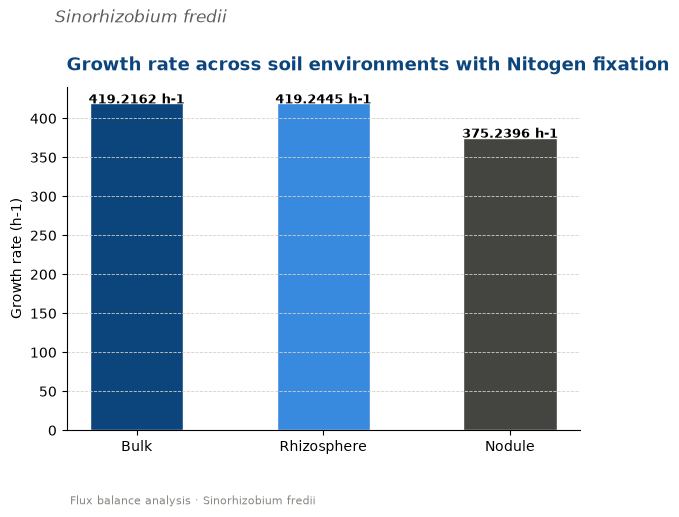

In [350]:
# N2 fixation rate
fig4, ax = plt.subplots(figsize=(6, 5))
mapping = {'Bulk': solution_bulk, 'Rhizosphere': solution_rh, 'Nodule': solution_no}
vals = [mapping[c].objective_value if getattr(mapping[c], "status", None) == "optimal" else 0 for c in conds]
bars = ax.bar(conds, vals, color=[COLORS[c] for c in conds], edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0003, f"{v:.4f} h-1", ha="center", fontsize=9, fontweight="bold")
fig4.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
ax.set_ylabel("Growth rate (h-1)")  
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Growth rate across soil environments with Nitogen fixation",
                fontsize=13, fontweight="bold", color="#0C447C",
                loc="left", pad=12)
fig4.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig4.savefig(os.path.join(save_path, "4_growth_rate_with_N2_fixation.png"), dpi=300)
plt.show()

plot 5: Fixed nitrogen over time

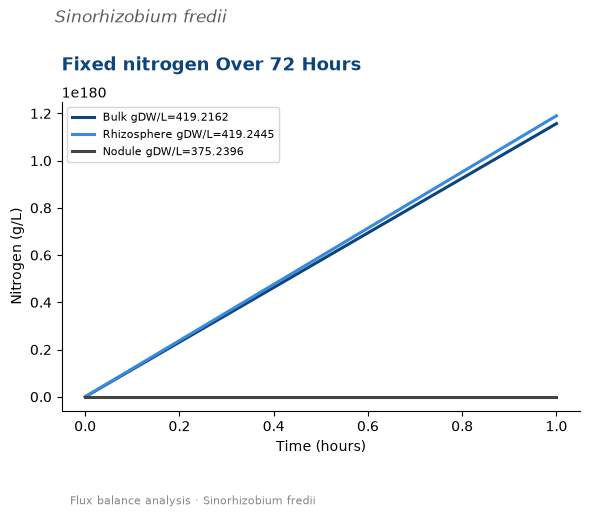

In [351]:
fig5, ax = plt.subplots(figsize=(6, 5))
for cond in conds:
    sub = nitrogen_df[nitrogen_df['Condition'] == cond].copy()
    sub = sub.rename(columns={'Time (hours)': 'time_h', 'Nitrogen (gDW/L)': 'nitrogen_gL'})
    mu = mapping[cond].objective_value
    ax.plot(sub.time_h, sub.nitrogen_gL, color=COLORS[cond], linewidth=2.2, label=f"{cond} gDW/L={mu:.4f}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Nitrogen (g/L)")
ax.set_title("Fixed nitrogen Over 72 Hours", fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig5.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig5.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig5.savefig(os.path.join(save_path, "5_N2_over_time.png"), dpi=300)
plt.show()

## PART 8: NITROGEN FIXATION
Maximum nitrogen fixation flux is recorded at each step from 0 to 90% of optimal.

This is done for each environment (Bluk soil, Rhizosphere, and Nodule) and for a nitrogen fixation.


NH3_id = "EX_cpdFixed_e0"

In [352]:
model.objective = NH3_id
solution = model.optimize()

n2_value = []

for n2 in f_values:
    model.reactions.get_by_id(biomass_id).lower_bound = n2*growth_rate
    solution = model.optimize()
    n2_value.append({
        "Fraction": n2,
        "Growth_rate": float(n2*growth_rate),
        "N2_rate_mmol_gDW_h": solution.objective_value
        
    })

# save 
df_n2 = pd.DataFrame(n2_value)
df_n2.to_csv(os.path.join(save_path,"n2_value.csv"), index=False)



In [353]:
df_n2

,Fraction,Growth_rate,N2_rate_mmol_gDW_h
0,0.0,0.000000,376.085000
1,0.1,0.095281,375.567046
2,0.2,0.190562,375.049092
3,0.3,0.285843,374.531138
4,0.4,0.381125,374.013184
5,0.5,0.476406,373.495230
6,0.6,0.571687,372.977276
7,0.7,0.666968,372.459322
8,0.8,0.762249,371.941368
9,0.9,0.857530,371.423414


Analyse biomass for each environment 

Bulk soil

In [354]:
model_bulk.objective = NH3_id
solution_bulk = model_bulk.optimize()

bulk_n2 = []
for bb in f_values:
    model_bulk.reactions.get_by_id(biomass_id).lower_bound = bb*max_growth_bulk
    solution_bulk = model_bulk.optimize()
    bulk_n2.append({
        "Environment": "Bulk soil",
        "Fraction": bb,
        "Growth_rate":  float(bb*max_growth_bulk),
        "N2_rate_mmol_gDW_h":  solution_bulk.objective_value,
    })

# save 
df_bulk_n2 = pd.DataFrame(bulk_n2)
df_bulk_n2.to_csv(os.path.join(save_path,"bulk_n2.csv"), index=False)

In [355]:
df_bulk_n2

,Environment,Fraction,Growth_rate,N2_rate_mmol_gDW_h
0,Bulk soil,0.0,0.0,419.216223
1,Bulk soil,0.1,0.0,419.216223
2,Bulk soil,0.2,0.0,419.216223
3,Bulk soil,0.3,0.0,419.216223
4,Bulk soil,0.4,0.0,419.216223
5,Bulk soil,0.5,0.0,419.216223
6,Bulk soil,0.6,0.0,419.216223
7,Bulk soil,0.7,0.0,419.216223
8,Bulk soil,0.8,0.0,419.216223
9,Bulk soil,0.9,0.0,419.216223


Rhizosphere

In [356]:
model_rh.objective = NH3_id
solution_rh = model_rh.optimize()

rh_n2 = []
for rh in f_values:
    model_rh.reactions.get_by_id(biomass_id).lower_bound = rh*max_growth_rh
    solution_rh = model_rh.optimize()
    rh_n2.append({
        "Environment": "Rhizosphere",
        "Fraction": rh,
        "Growth_rate":  float(rh*max_growth_rh),
        "N2_rate_mmol_gDW_h":  solution_rh.objective_value,
    })

# save 
df_rh_n2 = pd.DataFrame(rh_n2)
df_rh_n2.to_csv(os.path.join(save_path,"rhizosphere_n2.csv"), index=False)

In [357]:
df_rh_n2

,Environment,Fraction,Growth_rate,N2_rate_mmol_gDW_h
0,Rhizosphere,0.0,0.000000,419.244526
1,Rhizosphere,0.1,10.549561,403.666337
2,Rhizosphere,0.2,21.099122,388.031684
3,Rhizosphere,0.3,31.648683,372.397030
4,Rhizosphere,0.4,42.198244,341.937845
5,Rhizosphere,0.5,52.747805,304.276739
6,Rhizosphere,0.6,63.297366,266.615633
7,Rhizosphere,0.7,73.846927,228.921932
8,Rhizosphere,0.8,84.396488,190.608349
9,Rhizosphere,0.9,94.946049,142.012538


Nodule

In [358]:
model_no.objective = NH3_id
solution_no = model_no.optimize()

no_n2 = []
for no in f_values:
    model_no.reactions.get_by_id(biomass_id).lower_bound = no*max_growth_no
    solution_no = model_no.optimize()
    no_n2.append({
        "Environment": "Nodule",
        "Fraction": no,
        "Growth_rate":  float(no*max_growth_no),
        "N2_rate_mmol_gDW_h":  solution_no.objective_value,
    })

# save 
df_no_n2 = pd.DataFrame(no_n2)
df_no_n2.to_csv(os.path.join(save_path,"nodule_n2.csv"), index=False)

In [359]:
df_no_n2

,Environment,Fraction,Growth_rate,N2_rate_mmol_gDW_h
0,Nodule,0.0,0.000000,375.239550
1,Nodule,0.1,0.048296,374.977013
2,Nodule,0.2,0.096591,374.714476
3,Nodule,0.3,0.144887,374.451938
4,Nodule,0.4,0.193182,374.189401
5,Nodule,0.5,0.241478,373.926864
6,Nodule,0.6,0.289773,373.664327
7,Nodule,0.7,0.338069,373.401789
8,Nodule,0.8,0.386364,373.139252
9,Nodule,0.9,0.434660,372.876715


### PART 9: VISUALISATION

Combine dataframe

In [360]:
environments = [('Bulk', df_bulk, '#1f77b4'), ('Rhizosphere', df_rh, '#ff7f0e'), ('Nodule', df_no, '#2ca02c')]

Biomass growth rate 

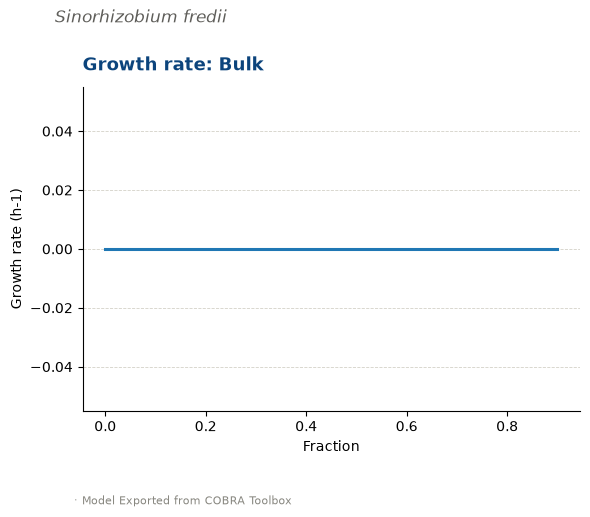

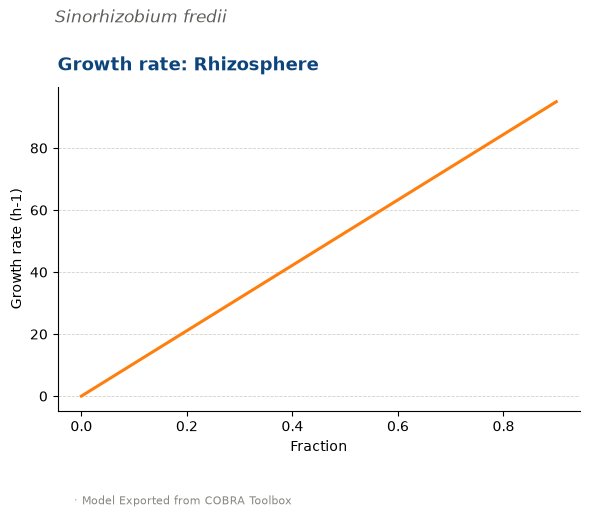

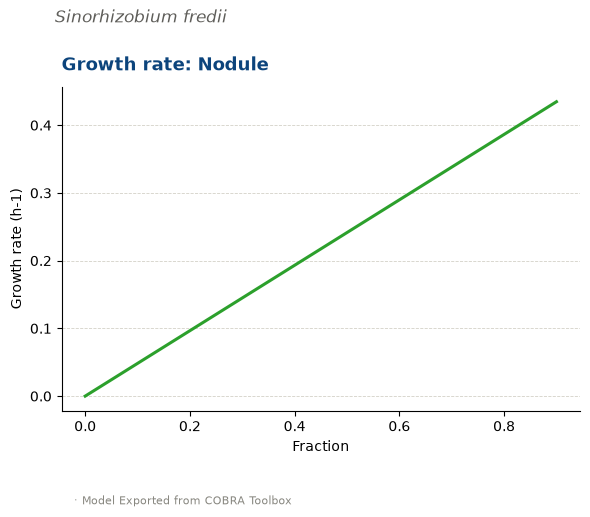

In [361]:
for name, df, color in environments:
    fig6, ax = plt.subplots(figsize=(6, 5))
    ax.plot(df['Fraction'], df['Biomass_rate_h-1'], color=color, linewidth=2.2)
    
    ax.set_ylabel("Growth rate (h-1)")
    ax.set_xlabel("Fraction")
    ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
    ax.set_title(f"Growth rate: {name}", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
    
    fig6.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
    fig6.text(0.125, -0.04, f" · {model.name}", fontsize=8, color="#888780", ha="left")
    ax.spines[["top","right"]].set_visible(False)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig6.savefig(os.path.join(save_path, f"6_growth_{name}.png"), dpi=300)

Nitrogen

In [362]:
environments = [('Bulk', df_bulk_n2, '#1f77b4'), ('Rhizosphere', df_rh_n2, '#ff7f0e'), ('Nodule', df_no_n2, '#2ca02c')]

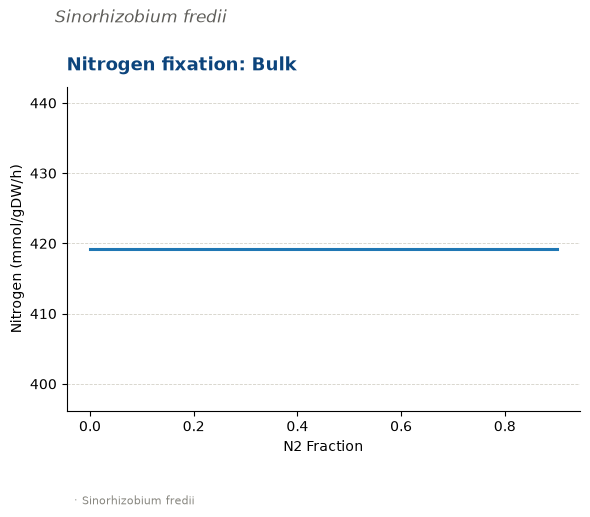

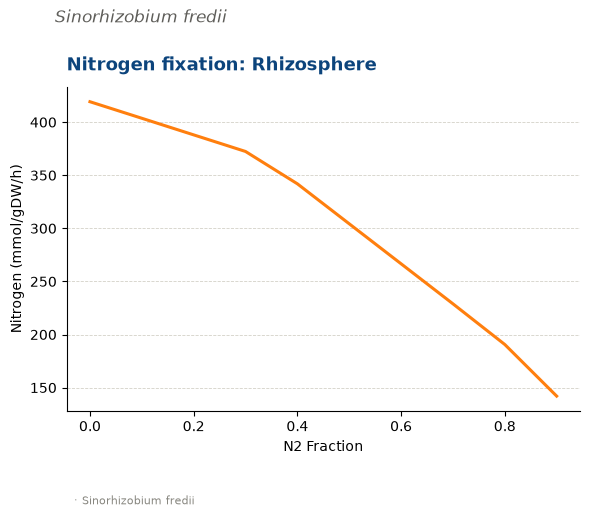

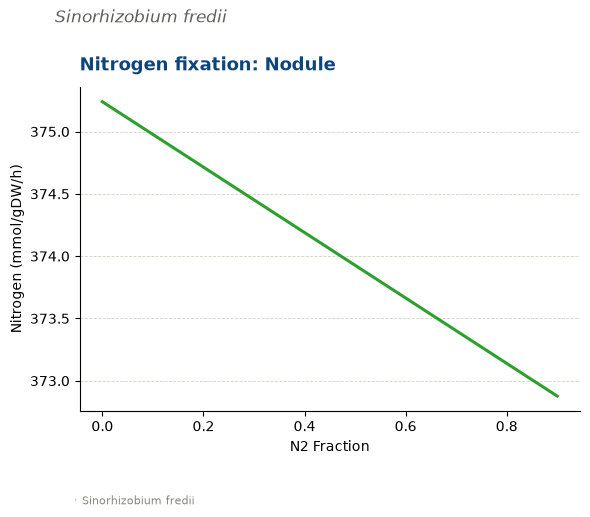

In [363]:
for name, df, color in environments:
    fig7, ax = plt.subplots(figsize=(6, 5))
    ax.plot(df['Fraction'], df['N2_rate_mmol_gDW_h'], color=color, linewidth=2.2)
    
    ax.set_ylabel("Nitrogen (mmol/gDW/h)")
    ax.set_xlabel("N2 Fraction")
    ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
    ax.set_title(f"Nitrogen fixation: {name}", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
    
    fig7.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
    fig7.text(0.125, -0.04, f" · {species_name}", fontsize=8, color="#888780", ha="left")
    ax.spines[["top","right"]].set_visible(False)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig7.savefig(os.path.join(save_path, f"7_n2_{name}.png"), dpi=300)

Combine biomass

In [364]:
environments = [('Bulk', df_bulk, '#1f77b4'), ('Rhizosphere', df_rh, '#ff7f0e'), ('Nodule', df_no, '#2ca02c')]

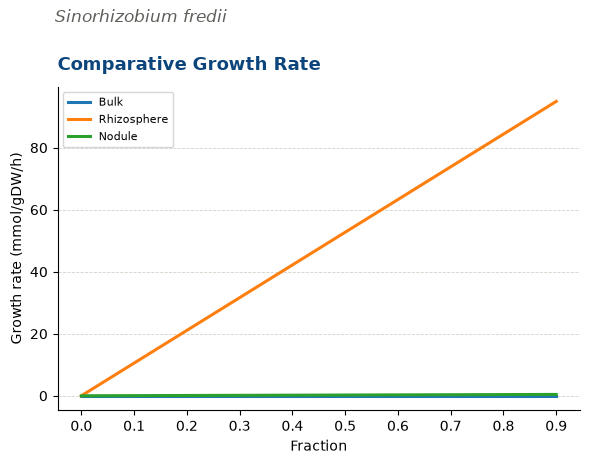

In [365]:
fig8, ax = plt.subplots(figsize=(6, 5))
for name, df, color in environments:
    ax.plot(df['Fraction'], df['Biomass_rate_h-1'], label=name, color=color, linewidth=2.2)

ax.set_ylabel("Growth rate (mmol/gDW/h)")
ax.set_xlabel("Fraction")
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Comparative Growth Rate", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig8.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
#fig8.text(0.125, -0.04, f" · {species_name}", fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=8)
x = f_values
plt.xticks(x)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig8.savefig(os.path.join(save_path, "8_combined_biomass.png"), dpi=300)
plt.show()

Combine nitrogen

In [366]:
environments = [('Bulk', df_bulk_n2, '#1f77b4'), ('Rhizosphere', df_rh_n2, '#ff7f0e'), ('Nodule', df_no_n2, '#2ca02c')]

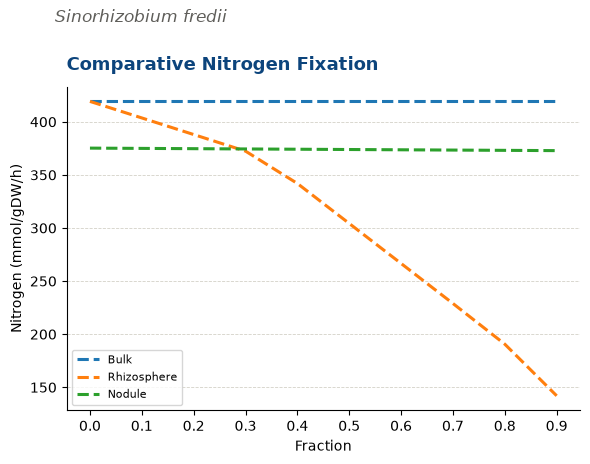

In [367]:
fig9, ax = plt.subplots(figsize=(6, 5))
for name, df, color in environments:
    ax.plot(df['Fraction'], df['N2_rate_mmol_gDW_h'], label=name, color=color, linewidth=2.2, linestyle="--")

ax.set_ylabel("Nitrogen (mmol/gDW/h)")
ax.set_xlabel("Fraction")
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Comparative Nitrogen Fixation", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig9.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
#fig9.text(0.125, -0.04, f" · {species_name}", fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=8)
x = f_values
plt.xticks(x)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig9.savefig(os.path.join(save_path, "9_combined_n2.png"), dpi=300)
plt.show()

Combine biomass and nitrogen

In [368]:
environments = {
    "Bulk": df_bulk_n2,
    "Rhizosphere": df_rh_n2,
    "Nodule": df_no_n2
}

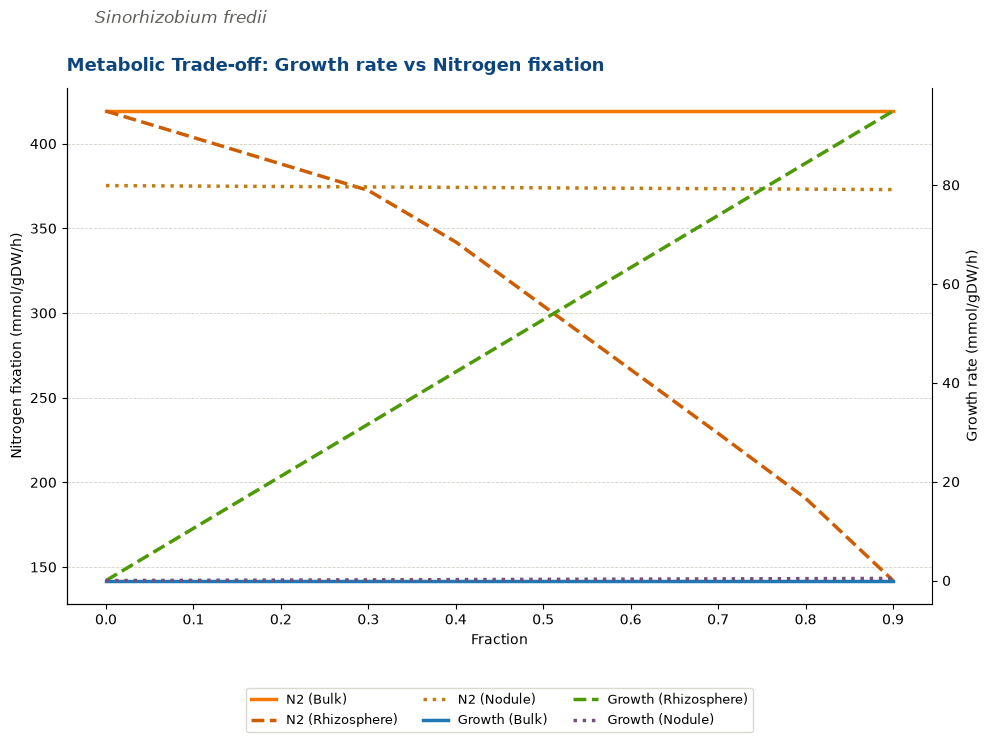

In [369]:
growth_colors = {'Bulk': '#1f77b4', 'Rhizosphere': '#4e9a06', 'Nodule': '#75507b'}
n2_colors = {'Bulk': '#f57900', 'Rhizosphere': '#ce5c00', 'Nodule': '#c17d11'}

linestyles = {'Bulk': '-', 'Rhizosphere': '--', 'Nodule': ':'}

fig10, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()

for name, df in environments.items():
    # Plot Nitrogen
    ax1.plot(df['Fraction'], df['N2_rate_mmol_gDW_h'], 
             color=n2_colors[name], 
             linestyle=linestyles[name], 
             linewidth=2.5, 
             label=f'N2 ({name})')
    # Plot Biomass (Growth)
    ax2.plot(df['Fraction'], df['Growth_rate'], 
             color=growth_colors[name], 
             linestyle=linestyles[name], 
             linewidth=2.5, 
             label=f'Growth ({name})')
    
    

ax1.set_xlabel("Fraction")
ax2.set_ylabel("Growth rate (mmol/gDW/h)") 
ax1.set_ylabel("Nitrogen fixation (mmol/gDW/h)")
ax1.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax2.set_title("Metabolic Trade-off: Growth rate vs Nitrogen fixation", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig10.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
#fig10.text(0.125, 0, f" · {species_name}", fontsize=8, color="#888780", ha="left")
ax2.spines[["top", "right"]].set_visible(False)
ax1.spines[["top"]].set_visible(False)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, 
           labels1 + labels2, 
           loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), 
           ncol=3, 
           frameon=True, 
           fontsize=9, 
           edgecolor='#D3D1C7')
x = f_values
plt.xticks(x)
plt.tight_layout(rect=[0, 0.01, 1, 0.95])
fig10.savefig(os.path.join(save_path, "10_integrated_tradeoff.png"), dpi=300)
plt.show()

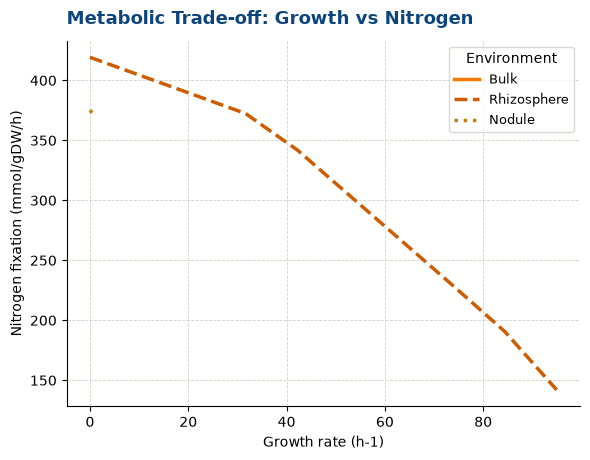

In [370]:
fig11, ax = plt.subplots(figsize=(6, 5))

for name, df in environments.items():
    ax.plot(df['Growth_rate'], 
            df['N2_rate_mmol_gDW_h'], 
            color=n2_colors[name], 
            linestyle=linestyles[name], 
            linewidth=2.5, 
            label=f'{name}')

ax.set_xlabel("Growth rate (h-1)")
ax.set_ylabel("Nitrogen fixation (mmol/gDW/h)")
ax.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Metabolic Trade-off: Growth vs Nitrogen", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig10.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc='upper right', frameon=True, fontsize=9, edgecolor='#D3D1C7', title="Environment")

plt.tight_layout(rect=[0, 0.01, 1, 0.95])
fig10.savefig(os.path.join(save_path, "11_growth_n2_tradeoff.png"), dpi=300)
plt.show()